<a href="https://colab.research.google.com/github/Devil-92/100_Days_of_ML/blob/main/PredictingElectricalVehicalPurchase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Kaggle Loading

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

Mounted at /content/gdrive


In [ ]:
!pip install -q --upgrade kaggle

In [ ]:
from google.colab import userdata

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = userdata.get('Token')

In [ ]:
import kaggle

print(kaggle.__version__)

2.2.4


In [ ]:
os.makedirs('/content/gdrive/MyDrive/Projects/Electric_Vehicle/', exist_ok=True)

In [ ]:
%cd /content/gdrive/MyDrive/Projects/Electric_Vehicle/

/content/gdrive/MyDrive/Projects/Electric_Vehicle


In [ ]:
!kaggle competitions download -c playground-series-s6e9

playground-series-s6e9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import glob
print(glob.glob('*.zip'))

['playground-series-s6e9.zip']


In [ ]:
!unzip -o playground-series-s6e9.zip -d data

Archive:  playground-series-s6e9.zip
  inflating: data/sample_submission.csv  
  inflating: data/test.csv           
  inflating: data/train.csv          


In [ ]:
print(os.listdir('data'))

['sample_submission.csv', 'test.csv', 'train.csv']


### Dataset Loading

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

In [ ]:
train_df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [ ]:
train_df.value_counts('Will_Buy_EV')

,count
Will_Buy_EV,
No,551886
Yes,116779


In [ ]:
train_df['Will_Buy_EV'] = train_df['Will_Buy_EV'].map({'Yes' : 1 , 'No' : 0})

In [ ]:
train_df.value_counts('Will_Buy_EV')

,count
Will_Buy_EV,
0,551886
1,116779


In [ ]:
train_df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0


In [ ]:
print('This is a case of imbalanced dataset')

This is a case of imbalanced dataset


In [ ]:
print('Size of train_df :' , train_df.shape)

Size of train_df : (668665, 15)


In [ ]:
print('Size of test_df :' , test_df.shape)

Size of test_df : (286571, 14)


In [ ]:
train_df.describe()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Will_Buy_EV
count,668665.00000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.00000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477,0.174645
std,193027.10321,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119,0.379663
min,0.00000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,167166.00000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000,0.000000
50%,334332.00000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000,0.000000
75%,501498.00000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000,0.000000
max,668664.00000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000,1.000000


In [ ]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286571 entries, 0 to 286570
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           286571 non-null  int64  
 1   Age                          286571 non-null  int64  
 2   Annual_Income_USD            286571 non-null  float64
 3   Daily_Commute_km             286571 non-null  float64
 4   Number_of_Cars_Owned         286571 non-null  int64  
 5   Charging_Stations_Near_Home  286571 non-null  int64  
 6   Charging_Stations_Near_Work  286571 non-null  int64  
 7   Environmental_Concern_Level  286571 non-null  float64
 8   Gender                       286571 non-null  object 
 9   City_Type                    286571 non-null  object 
 10  Current_Car_Type             286571 non-null  object 
 11  Home_Charging_Possible       286571 non-null  object 
 12  Subsidy_Available            286571 non-null  object 
 13 

In [ ]:
print(train_df.isnull().sum())

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64


In [ ]:
print(test_df.isnull().sum())

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
dtype: int64


In [ ]:
print('From what we can infer our dataset had no null values')

From what we can infer our dataset had no null values


In [ ]:
train_df.iloc[:, 0]

,id
0,0
1,1
2,2
3,3
4,4
...,...
668660,668660
668661,668661
668662,668662
668663,668663


In [ ]:
print('Id column will act as out primary indexing column')

Id column will act as out primary indexing column


In [ ]:
train_id = train_df.iloc[: , 0]

In [ ]:
test_id = test_df.iloc[: , 0]

In [ ]:
test_id.head()

,id
0,668665
1,668666
2,668667
3,668668
4,668669


In [ ]:
train_df.drop('id' , axis = 1 , inplace = True)

In [ ]:
test_df.drop('id' , axis = 1 , inplace = True)

In [ ]:
train_df.describe(include = 'all')

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665,668665,668665,668665,668665,668665,668665.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,4,2,2,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,Urban,Sedan,Yes,Yes,Low,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,367954,289305,303459,462677,419909,603972,NaN
mean,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477,NaN,NaN,NaN,NaN,NaN,NaN,0.174645
std,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119,NaN,NaN,NaN,NaN,NaN,NaN,0.379663
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
num_cols = train_df.select_dtypes(['int64' , 'float64'])

In [ ]:
len(num_cols.columns)

8

In [ ]:
cat_cols = train_df.select_dtypes(['object']).columns.to_list()

In [ ]:
cat_cols

['Gender',
 'City_Type',
 'Current_Car_Type',
 'Home_Charging_Possible',
 'Subsidy_Available',
 'Range_Anxiety_Level']

In [ ]:
len(cat_cols)

6

In [ ]:
len(cat_cols) + len(num_cols.columns) == len(train_df.columns)

True

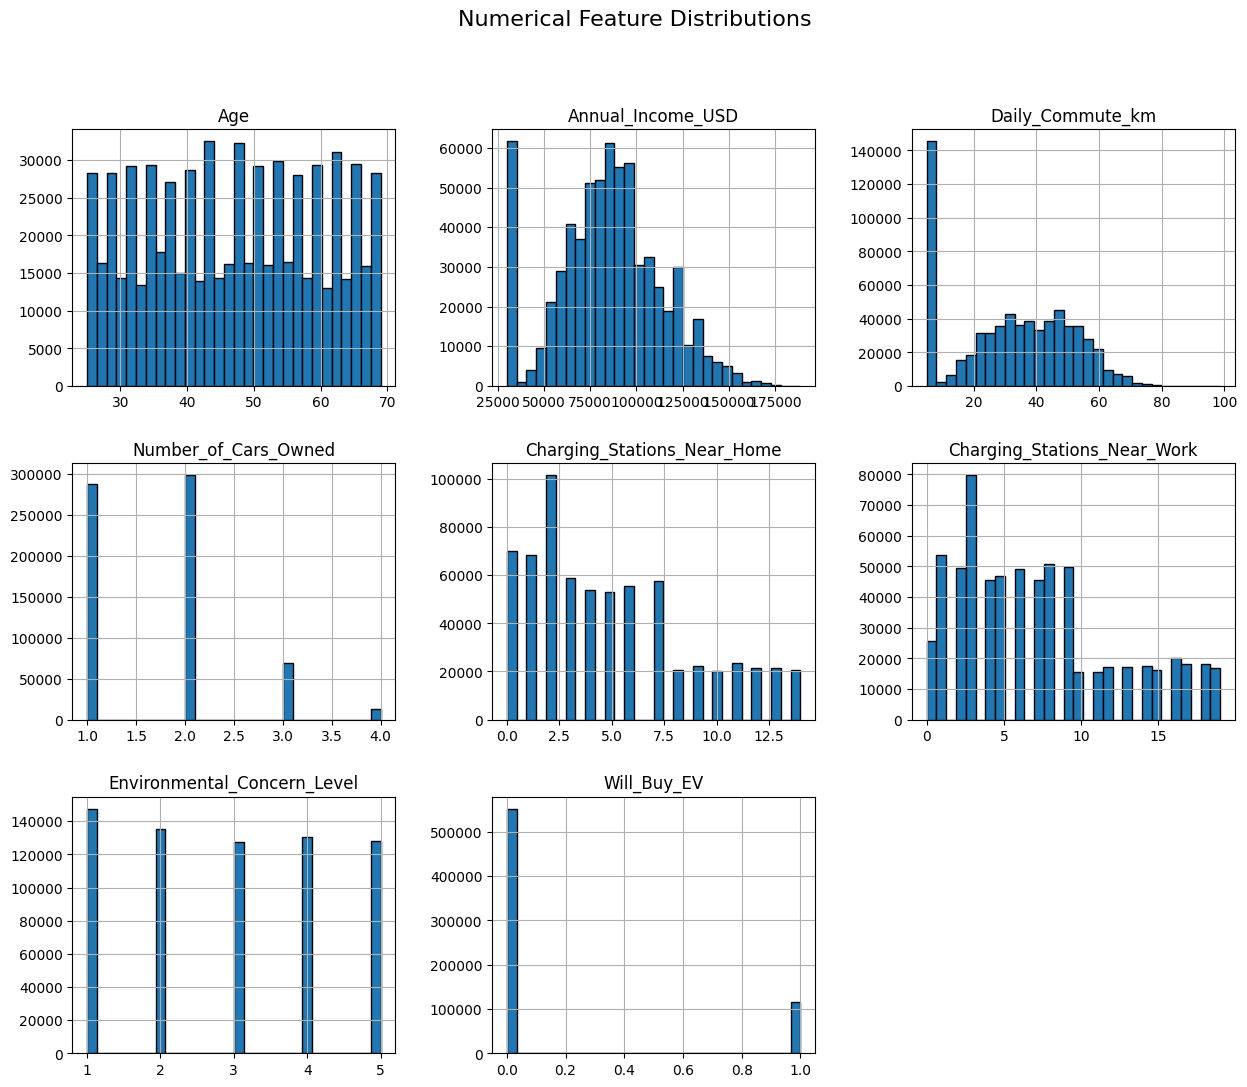

In [ ]:
num_cols.hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle("Numerical Feature Distributions", fontsize=16)
plt.show()

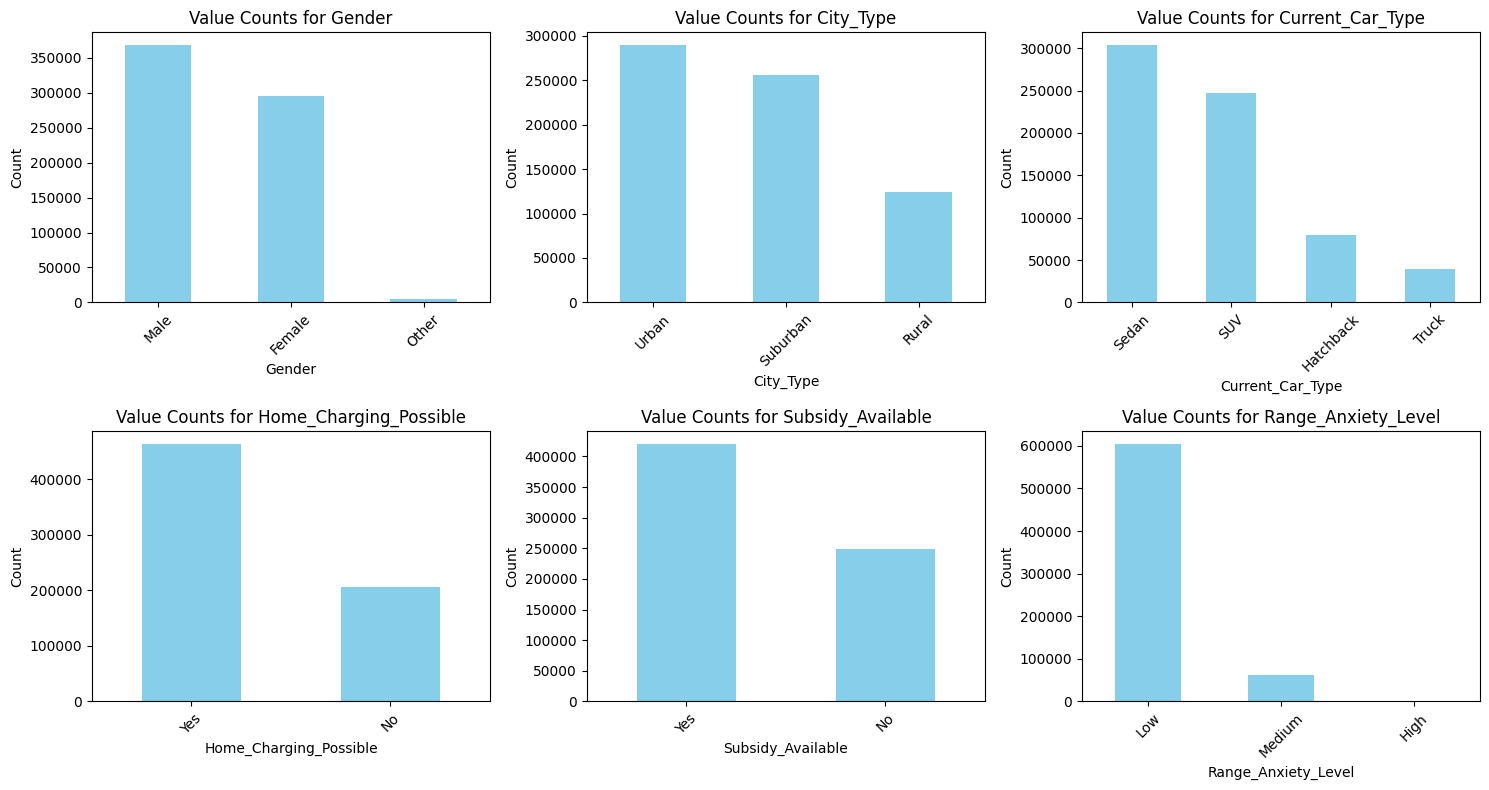

In [ ]:
import math
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig , axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    train_df[col].value_counts().plot(kind="bar", color="skyblue", ax=axes[i])
    axes[i].set_title(f"Value Counts for {col}")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

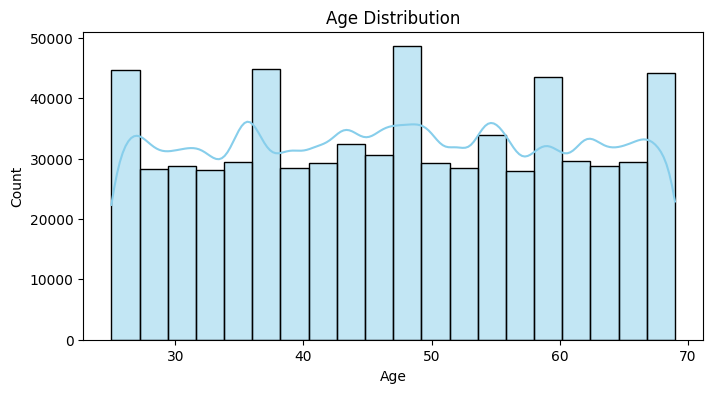

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(train_df['Age'], kde=True, bins=20, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

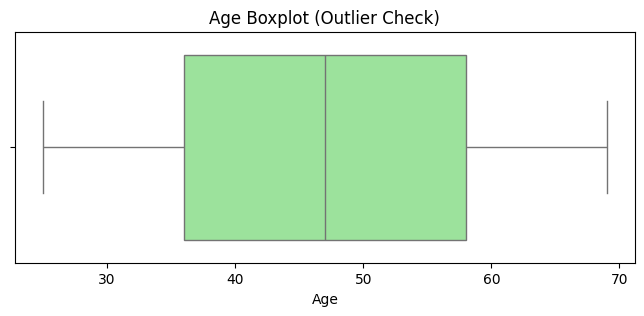

In [ ]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=train_df['Age'], color='lightgreen')
plt.title('Age Boxplot (Outlier Check)')
plt.xlabel('Age')
plt.show()

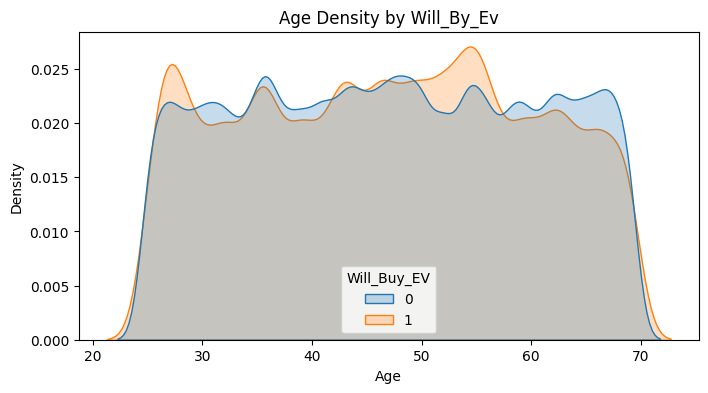

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.kdeplot(data=train_df, x='Age', hue='Will_Buy_EV', common_norm=False, fill=True)
plt.title('Age Density by Will_By_Ev')
plt.show()

In [ ]:
print("I don't age column needed binning as a moreover uniform distribution is there little spikes in between" )

I don't age column needed binning as a moreover uniform distribution is there little spikes in between


In [ ]:
train_df["Daily_Commute_km"]

,Daily_Commute_km
0,23.4
1,5.0
2,36.8
3,23.7
4,50.8
...,...
668660,27.4
668661,5.0
668662,24.2
668663,43.7


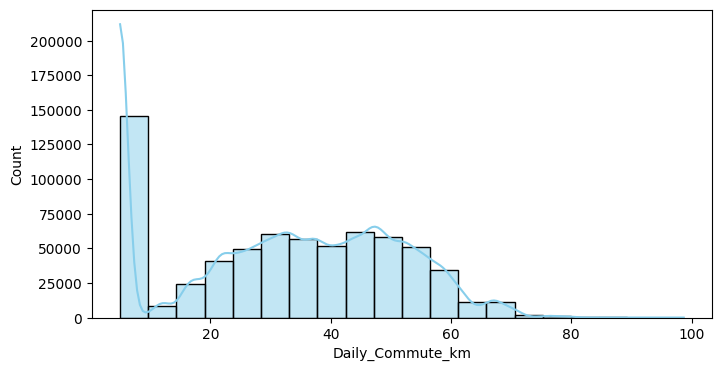

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(train_df['Daily_Commute_km'], kde=True, bins=20, color='skyblue')
plt.show()

In [ ]:
train_df['Daily_Commute_km'].value_counts()

,count
Daily_Commute_km,
5.0,144280
46.6,2756
48.5,2720
33.0,2562
53.3,2546
...,...
83.0,1
77.9,1
89.3,1


In [ ]:
print('This is zero inflated or say mixture of two distribution')

This is zero inflated or say mixture of two distribution


In [ ]:
print('The near distance are the work from home team')

The near distance are the work from home team


In [ ]:
def wfh(df):
  df['is_wfh'] = (df['Daily_Commute_km'] <= 10).astype(int)

In [ ]:
wfh(train_df)

In [ ]:
wfh(test_df)

In [ ]:
def norm_dist(df) :
  df['commute_km_clean'] = df['Daily_Commute_km'].where(df['Daily_Commute_km'] > 10)

In [ ]:
norm_dist(train_df)
norm_dist(test_df)

In [ ]:
train_df.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,is_wfh,commute_km_clean
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0,0,23.4
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0,1,NaN
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1,0,36.8
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0,0,23.7
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0,0,50.8


In [ ]:
train_df['commute_km_clean'] = train_df['commute_km_clean'].fillna(0)
test_df['commute_km_clean'] = test_df['commute_km_clean'].fillna(0)

In [ ]:
def bucketing_dist(df) :
  df['commute_brackets'] = pd.cut(df['commute_km_clean'] , bins = [-1 , 10 , 30 , 60 , np.inf] , labels = ['wfh' , 'short_trav' , 'medium_trav' , 'long_trav'])

In [ ]:
bucketing_dist(train_df)
bucketing_dist(test_df)

In [ ]:
train_df.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,is_wfh,commute_km_clean,commute_brackets
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0,0,23.4,short_trav
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0,1,0.0,wfh
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1,0,36.8,medium_trav
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0,0,23.7,short_trav
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0,0,50.8,medium_trav


In [ ]:
train_df.groupby(by = 'commute_brackets' , observed = True)['Will_Buy_EV'].mean()

,Will_Buy_EV
commute_brackets,
wfh,0.184457
short_trav,0.197414
medium_trav,0.167527
long_trav,0.106870


In [ ]:
train_df.drop(['is_wfh' , 'Daily_Commute_km'] , axis = 1 , inplace = True)

In [ ]:
test_df.drop(['is_wfh' , 'Daily_Commute_km'] , axis = 1 , inplace = True)

In [ ]:
len(train_df.columns)

15

In [ ]:
len(test_df.columns)

14

In [ ]:
train_df.loc[: , 'Annual_Income_USD']

,Annual_Income_USD
0,92887.0
1,30000.0
2,94389.0
3,73580.0
4,57898.0
...,...
668660,71090.0
668661,129990.0
668662,121791.0
668663,115923.0


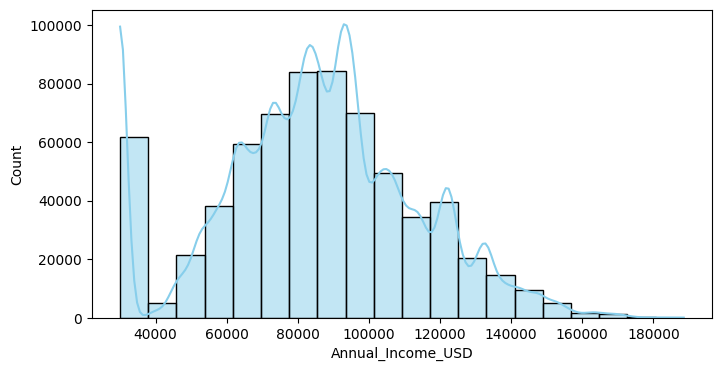

In [ ]:
figsize = plt.figure(figsize = (8 , 4))
sns.histplot(train_df['Annual_Income_USD'], kde=True, bins=20, color='skyblue')
plt.show()

In [ ]:
train_df['Annual_Income_USD'].value_counts().head(10)

,count
Annual_Income_USD,
30000.0,61605
86095.0,1082
96749.0,1073
65800.0,1029
92372.0,907
84578.0,905
93957.0,852
68480.0,762
82440.0,739


In [ ]:
print('Clearly 30000 is a sentinal Value')

Clearly 30000 is a sentinal Value


In [ ]:
train_df['income_unknown'] = (train_df['Annual_Income_USD'] == 30000).astype(int)

In [ ]:
test_df['income_unknown'] = (test_df['Annual_Income_USD'] == 30000).astype(int)

In [ ]:
train_df.groupby('income_unknown')['Will_Buy_EV'].mean()

,Will_Buy_EV
income_unknown,
0,0.187876
1,0.044266


In [ ]:
print('It clearly have a stand on its own')

It clearly have a stand on its own


In [ ]:
print('Keeping It as it is worth is for both tree and lb models')

Keeping It as it is worth is for both tree and lb models


In [ ]:
train_df["Charging_Stations_Near_Work"]

,Charging_Stations_Near_Work
0,7
1,2
2,15
3,9
4,3
...,...
668660,6
668661,4
668662,6
668663,0


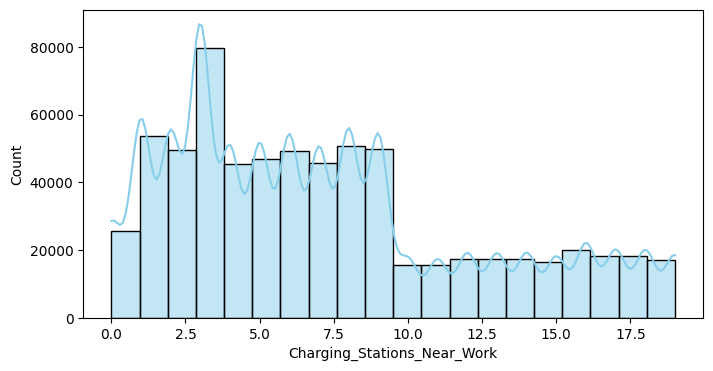

In [ ]:
figsize = plt.figure(figsize = (8 , 4))
sns.histplot(train_df['Charging_Stations_Near_Work'], kde=True, bins=20, color='skyblue')
plt.show()

In [ ]:
print('Pretty good to me we can keep this column as it is')

Pretty good to me we can keep this column as it is


In [ ]:
train_df["Environmental_Concern_Level"]

,Environmental_Concern_Level
0,1.0
1,4.0
2,5.0
3,3.0
4,3.0
...,...
668660,5.0
668661,1.0
668662,1.0
668663,1.0


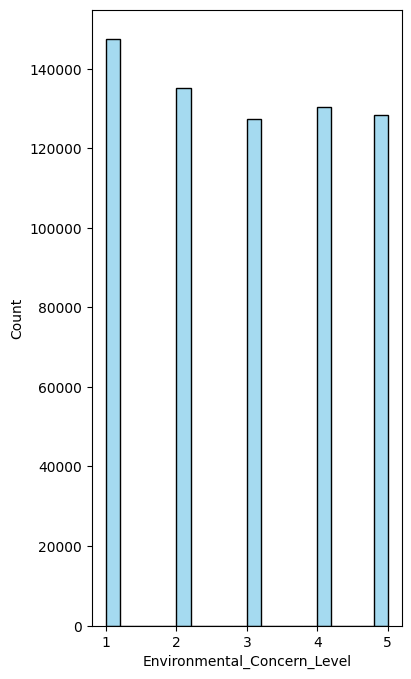

In [ ]:
plt.figure(figsize = (4 ,8))
sns.histplot(train_df['Environmental_Concern_Level'] , bins = 20 , color = 'skyblue')
plt.show()

In [ ]:
train_df.groupby('Environmental_Concern_Level')['Will_Buy_EV'].mean()

,Will_Buy_EV
Environmental_Concern_Level,
1.0,0.005655
2.0,0.021379
3.0,0.110922
4.0,0.248848
5.0,0.518287


In [ ]:
print('It is monotonic hence it will just go with both tree and logistic models')

It is monotonic hence it will just go with both tree and logistic models


In [ ]:
train_df['Charging_Stations_Near_Work']

,Charging_Stations_Near_Work
0,7
1,2
2,15
3,9
4,3
...,...
668660,6
668661,4
668662,6
668663,0


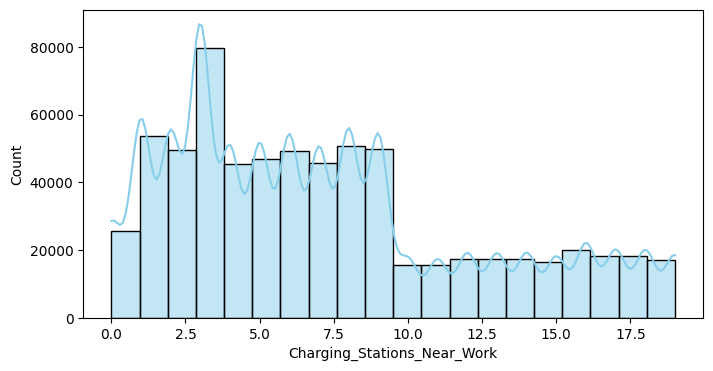

In [ ]:
figsize = plt.figure(figsize = (8 , 4))
sns.histplot(train_df['Charging_Stations_Near_Work'], kde=True, bins=20, color='skyblue')
plt.show()

In [ ]:
train_df['Number_of_Cars_Owned'].value_counts(normalize = True)

,proportion
Number_of_Cars_Owned,
2,0.446093
1,0.430727
3,0.103007
4,0.020173


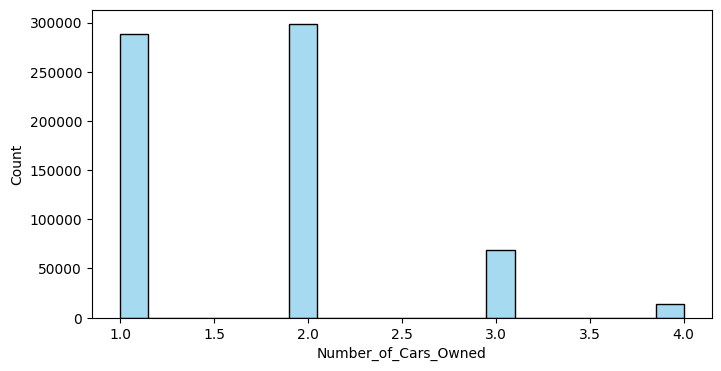

In [ ]:
figsize = plt.figure(figsize = (8 , 4))
sns.histplot(train_df['Number_of_Cars_Owned'] ,  bins=20, color='skyblue')
plt.show()

In [ ]:
train_df['Gender']

,Gender
0,Male
1,Male
2,Female
3,Male
4,Male
...,...
668660,Male
668661,Female
668662,Female
668663,Female


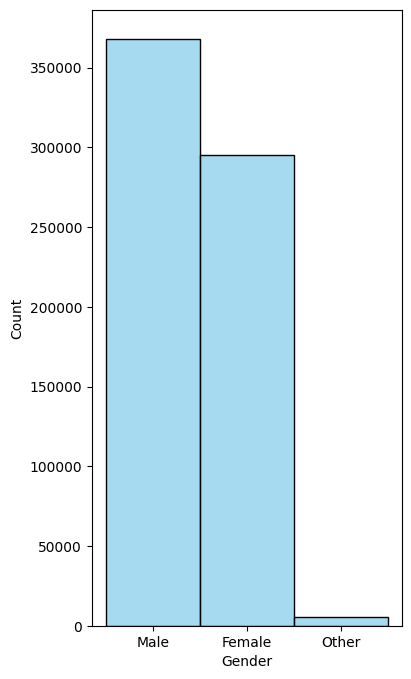

In [ ]:
plt.figure(figsize = (4 ,8))
sns.histplot(train_df['Gender'] , bins = 20 , color = 'skyblue')
plt.show()

In [ ]:
train_df.groupby('Gender')['Will_Buy_EV'].mean()

,Will_Buy_EV
Gender,
Female,0.177641
Male,0.172253
Other,0.173732


In [ ]:
train_df["City_Type"]

,City_Type
0,Suburban
1,Rural
2,Urban
3,Suburban
4,Suburban
...,...
668660,Urban
668661,Suburban
668662,Suburban
668663,Rural


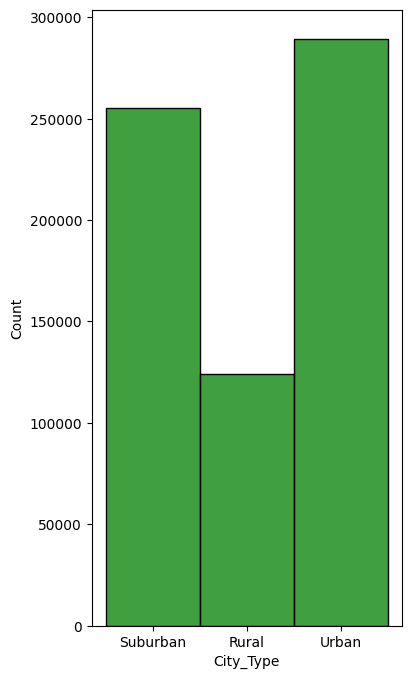

In [ ]:
plt.figure(figsize = (4 , 8))
sns.histplot(train_df['City_Type'] , bins = 20 , color = 'green')
plt.show()

In [ ]:
train_df.groupby('City_Type', observed=True)['Will_Buy_EV'].mean()

,Will_Buy_EV
City_Type,
Rural,0.193389
Suburban,0.180936
Urban,0.161058


In [ ]:
print('Looks genuine enough')

Looks genuine enough


In [ ]:
train_df["Current_Car_Type"]

,Current_Car_Type
0,Sedan
1,SUV
2,Sedan
3,Hatchback
4,Hatchback
...,...
668660,Sedan
668661,SUV
668662,Hatchback
668663,SUV


In [ ]:
train_df['Current_Car_Type'].nunique()

4

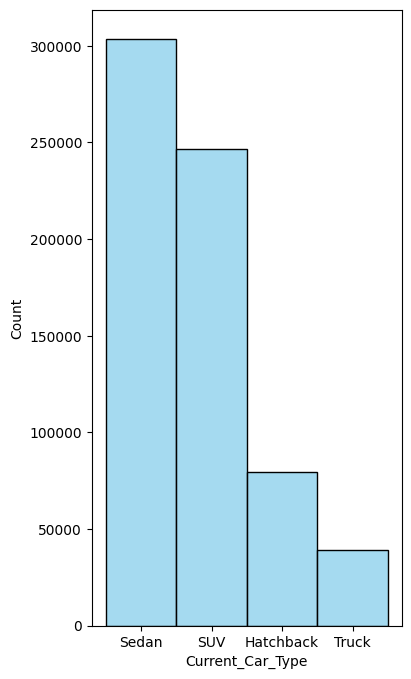

In [ ]:
plt.figure(figsize = (4 , 8))
sns.histplot(train_df['Current_Car_Type'] , color = 'skyblue')
plt.show()

In [ ]:
train_df.groupby('Current_Car_Type')['Will_Buy_EV'].mean()

,Will_Buy_EV
Current_Car_Type,
Hatchback,0.174299
SUV,0.180953
Sedan,0.171967
Truck,0.156413


In [ ]:
train_df["Home_Charging_Possible"]

,Home_Charging_Possible
0,Yes
1,Yes
2,No
3,Yes
4,Yes
...,...
668660,No
668661,Yes
668662,Yes
668663,Yes


In [ ]:
train_df['Home_Charging_Possible'].value_counts()

,count
Home_Charging_Possible,
Yes,462677
No,205988


In [ ]:
train_df.groupby('Home_Charging_Possible')['Will_Buy_EV'].mean()

,Will_Buy_EV
Home_Charging_Possible,
No,0.127085
Yes,0.195819


In [ ]:
train_df["Subsidy_Available"]

,Subsidy_Available
0,No
1,No
2,Yes
3,No
4,No
...,...
668660,Yes
668661,Yes
668662,Yes
668663,Yes


In [ ]:
for i in range(6 , 13) :
  print(train_df.iloc[: , i].nunique())

3
3
4
2
2
3
2


In [ ]:
for i in range(6 , 13) :
  print(train_df.groupby(train_df.columns[i] , observed = True)['Will_Buy_EV'].mean())
  print()

Gender
Female    0.177641
Male      0.172253
Other     0.173732
Name: Will_Buy_EV, dtype: float64

City_Type
Rural       0.193389
Suburban    0.180936
Urban       0.161058
Name: Will_Buy_EV, dtype: float64

Current_Car_Type
Hatchback    0.174299
SUV          0.180953
Sedan        0.171967
Truck        0.156413
Name: Will_Buy_EV, dtype: float64

Home_Charging_Possible
No     0.127085
Yes    0.195819
Name: Will_Buy_EV, dtype: float64

Subsidy_Available
No     0.005757
Yes    0.274695
Name: Will_Buy_EV, dtype: float64

Range_Anxiety_Level
High      0.001367
Low       0.189027
Medium    0.041745
Name: Will_Buy_EV, dtype: float64

Will_Buy_EV
0    0.0
1    1.0
Name: Will_Buy_EV, dtype: float64



In [ ]:
print('The Subsidy seems sus')

The Subsidy seems sus


In [ ]:
pd.crosstab(train_df['Subsidy_Available'], train_df['Will_Buy_EV'], normalize='index')

Will_Buy_EV,0,1
Subsidy_Available,,
No,0.994243,0.005757
Yes,0.725305,0.274695


In [ ]:
train_df['Subsidy_Available'].value_counts(normalize=True)

,proportion
Subsidy_Available,
Yes,0.627981
No,0.372019


In [ ]:
print('We have a good proportion of yes no and the convert rate of subsidy available yes to will buy is also normal')

We have a good proportion of yes no and the convert rate of subsidy available yes to will buy is also normal


In [ ]:
len(train_df.columns)

16

In [ ]:
len(test_df.columns)

14

In [ ]:
print('Now we will look for any multicorrelation')

Now we will look for any multicorrelation


In [ ]:
num_cols = train_df.select_dtypes([np.number])

In [ ]:
num_cols.corr()

,Age,Annual_Income_USD,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Will_Buy_EV,commute_km_clean,income_unknown
Age,1.000000,-0.004559,-0.002028,-0.004133,-0.005855,-0.003703,-0.007450,-0.006528,0.005248
Annual_Income_USD,-0.004559,1.000000,-0.000154,-0.008646,-0.002770,0.076405,0.225729,0.008493,-0.609024
Number_of_Cars_Owned,-0.002028,-0.000154,1.000000,0.008495,0.008611,-0.000579,0.003896,0.002827,-0.006901
Charging_Stations_Near_Home,-0.004133,-0.008646,0.008495,1.000000,0.511134,-0.011332,-0.016353,0.044284,-0.003391
Charging_Stations_Near_Work,-0.005855,-0.002770,0.008611,0.511134,1.000000,-0.007833,-0.012229,0.035224,-0.009848
Environmental_Concern_Level,-0.003703,0.076405,-0.000579,-0.011332,-0.007833,1.000000,0.464079,-0.017666,-0.027605
Will_Buy_EV,-0.007450,0.225729,0.003896,-0.016353,-0.012229,0.464079,1.000000,-0.043582,-0.109396
commute_km_clean,-0.006528,0.008493,0.002827,0.044284,0.035224,-0.017666,-0.043582,1.000000,-0.010837
income_unknown,0.005248,-0.609024,-0.006901,-0.003391,-0.009848,-0.027605,-0.109396,-0.010837,1.000000


In [ ]:
corr_mat = train_df.corr(numeric_only = True)

[]

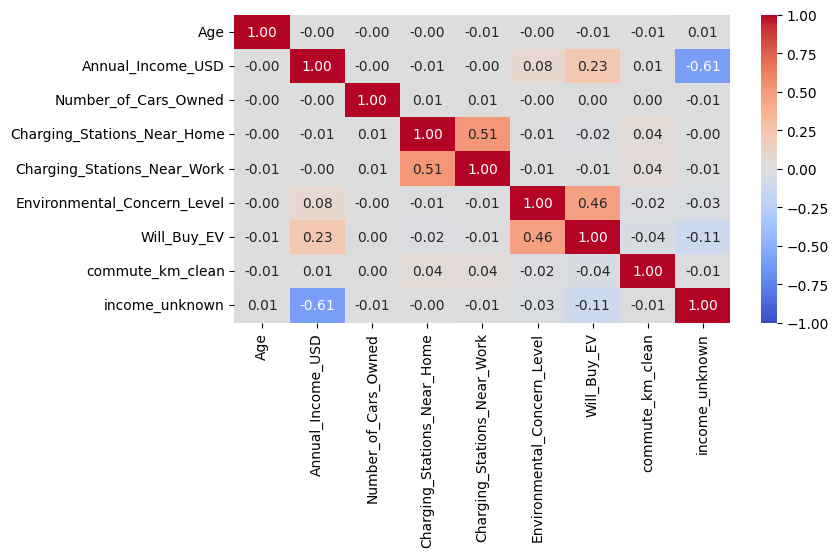

In [ ]:
plt.figure(figsize = (8 , 4))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.plot()

In [ ]:
corr_with_target = train_df.corrwith(train_df['Will_Buy_EV'], numeric_only=True).sort_values(ascending=False)

In [ ]:
corr_with_target

,0
Will_Buy_EV,1.000000
Environmental_Concern_Level,0.464079
Annual_Income_USD,0.225729
Number_of_Cars_Owned,0.003896
Age,-0.007450
Charging_Stations_Near_Work,-0.012229
Charging_Stations_Near_Home,-0.016353
commute_km_clean,-0.043582
income_unknown,-0.109396


In [ ]:
print("We will use Cramver's V for Categorical Values ")

We will use Cramver's V for Categorical Values 


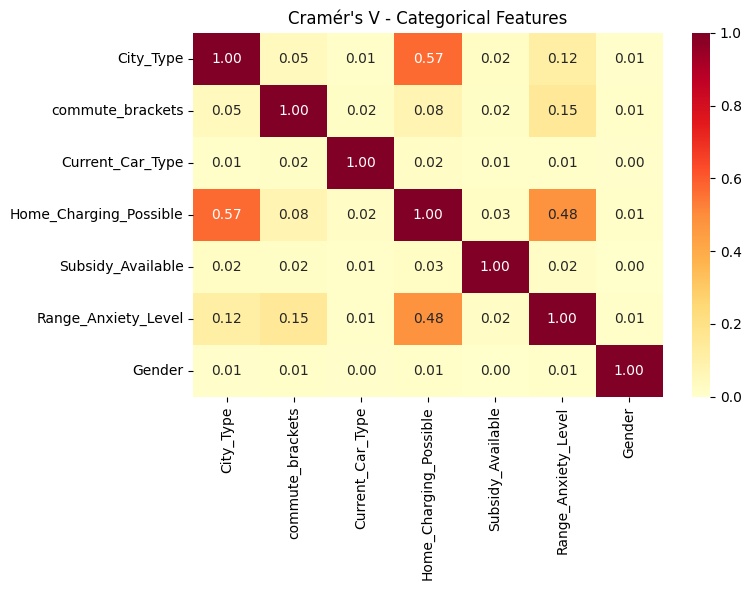

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y) :
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion.shape) - 1)))

cat_cols = ['City_Type', 'commute_brackets', 'Current_Car_Type',
            'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Gender']

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        cramers_matrix.loc[c1, c2] = cramers_v(train_df[c1], train_df[c2])

plt.figure(figsize=(8, 6))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1)
plt.title('Cramér\'s V - Categorical Features')
plt.tight_layout()
plt.show()

In [ ]:
train_df.isna().sum()

,0
Age,0
Annual_Income_USD,0
Number_of_Cars_Owned,0
Charging_Stations_Near_Home,0
Charging_Stations_Near_Work,0
Environmental_Concern_Level,0
Gender,0
City_Type,0
Current_Car_Type,0
Home_Charging_Possible,0


In [ ]:
test_df.isna().sum()

,0
Age,0
Annual_Income_USD,0
Number_of_Cars_Owned,0
Charging_Stations_Near_Home,0
Charging_Stations_Near_Work,0
Environmental_Concern_Level,0
Gender,0
City_Type,0
Current_Car_Type,0
Home_Charging_Possible,0


In [ ]:
len(train_df.columns) - 1 == len(test_df.columns)

True

In [ ]:
train_df.columns

Index(['Age', 'Annual_Income_USD', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Gender', 'City_Type',
       'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available',
       'Range_Anxiety_Level', 'Will_Buy_EV', 'commute_km_clean',
       'commute_brackets', 'income_unknown'],
      dtype='object')

In [ ]:
train_df['income_unknown'] = train_df['income_unknown'].map({1 : 'Yes' , 0 : 'No'})

In [ ]:
test_df['income_unknown'] = test_df['income_unknown'].map({1 : 'Yes' , 0 : 'No'})

In [ ]:
train_df['income_unknown'].value_counts()

,count
income_unknown,
No,607060
Yes,61605


In [ ]:
test_df['income_unknown'].value_counts()

,count
income_unknown,
No,260295
Yes,26276


In [ ]:
from sklearn.preprocessing import OneHotEncoder , StandardScaler , OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_cols = ['Age', 'Annual_Income_USD', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'commute_km_clean' ]

nom_cols = ['Gender', 'City_Type', 'Current_Car_Type', 'commute_brackets']

bin_cols = ['Home_Charging_Possible', 'Subsidy_Available' , 'income_unknown']

ord_col = ['Range_Anxiety_Level']
ord_order = [['Low', 'Medium', 'High']]

lr_preprocessor = ColumnTransformer(transformers = [
    ('num', StandardScaler(), num_cols),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nom_cols),
    ('bin', OneHotEncoder(drop='first', handle_unknown='ignore'), bin_cols),
    ('ord', OrdinalEncoder(categories=ord_order), ord_col),
])

from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocess', lr_preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

In [ ]:
from sklearn.impute import SimpleImputer
tree_preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols) ,
    ('nom', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), nom_cols),
    ('bin', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), bin_cols),
    ('ord', OrdinalEncoder(categories=ord_order), ord_col),
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocess', tree_preprocessor),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

In [ ]:
from xgboost import XGBClassifier

neg, pos = train_df['Will_Buy_EV'].value_counts()
scale_pos_weight = neg / pos

xgb_pipeline = Pipeline(steps=[
    ('preprocess', tree_preprocessor),
    ('clf', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

X = train_df.drop(columns=['Will_Buy_EV'])
y = train_df['Will_Buy_EV']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['roc_auc', 'average_precision', 'f1', 'recall', 'precision']

models = {
    'LogisticRegression': lr_pipeline,
    'RandomForest': rf_pipeline,
    'XGBoost': xgb_pipeline
}

results = []

for name, pipeline in models.items():
    cv_results = cross_validate(
        pipeline, X, y,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {'model': name}
    for metric in scoring:
        scores = cv_results[f'test_{metric}']
        row[f'{metric}_mean'] = scores.mean()
        row[f'{metric}_std'] = scores.std()
    results.append(row)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('roc_auc_mean', ascending=False)
results_df

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,model,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std
2,XGBoost,0.941084,0.000788,0.753373,0.002865,0.687410,0.001825,0.909984,0.002117,0.552320,0.001978
0,LogisticRegression,0.938260,0.000796,0.741604,0.003423,0.686301,0.001580,0.896411,0.002207,0.555985,0.001604
1,RandomForest,0.933066,0.000761,0.724642,0.003299,0.673911,0.001957,0.633376,0.003125,0.720003,0.002358


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_pipeline.set_params(clf__tree_method='hist')

xgb_param_dist = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 4, 5, 6],
    'clf__learning_rate': [0.03, 0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'clf__min_child_weight': [1, 3, 5],
}

random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring='average_precision',
    cv=skf,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X, y)
print(random_search.best_params_)
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'clf__subsample': 0.9, 'clf__n_estimators': 300, 'clf__min_child_weight': 5, 'clf__max_depth': 3, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 0.7}
0.756178768375917


In [ ]:
test_df.columns.tolist()

['Age',
 'Annual_Income_USD',
 'Number_of_Cars_Owned',
 'Charging_Stations_Near_Home',
 'Charging_Stations_Near_Work',
 'Environmental_Concern_Level',
 'Gender',
 'City_Type',
 'Current_Car_Type',
 'Home_Charging_Possible',
 'Subsidy_Available',
 'Range_Anxiety_Level',
 'commute_km_clean',
 'commute_brackets',
 'income_unknown']

In [ ]:
from sklearn.model_selection import train_test_split

X_full = train_df.drop(columns=['Will_Buy_EV'])
y_full = train_df['Will_Buy_EV']

X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y_full, test_size=0.15, stratify=y_full, random_state=42
)

In [ ]:
expected_cols = num_cols + nom_cols + bin_cols + ord_col
missing_in_test = set(expected_cols) - set(test_df.columns)
print(missing_in_test)

set()


In [ ]:
test_id.head()

,id
0,668665
1,668666
2,668667
3,668668
4,668669


In [ ]:
len(test_df) == len(test_id)

True

In [ ]:
best_model = random_search.best_estimator_

X_test = test_df
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

predictions_df = pd.DataFrame({
    'id': test_id,
    'Will_Buy_EV_probability': y_proba
})
predictions_df.to_csv('/content/gdrive/MyDrive/Projects/Electric_Vehicle/ev_predictions.csv', index=False)

In [ ]:
submission = pd.read_csv('/content/gdrive/MyDrive/Projects/Electric_Vehicle/ev_predictions.csv')

In [ ]:
submission.head()

,id,Will_Buy_EV_probability
0,668665,0.047090
1,668666,0.099791
2,668667,0.020740
3,668668,0.012392
4,668669,0.098334


In [ ]:
xgb_pipeline.fit(X_tr, y_tr)
lr_pipeline.fit(X_tr, y_tr)

xgb_val_proba = xgb_pipeline.predict_proba(X_val)[:, 1]
lr_val_proba = lr_pipeline.predict_proba(X_val)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

best_score = 0
best_w = 0

for w in np.arange(0, 1.05, 0.05):
    blended = w * xgb_val_proba + (1 - w) * lr_val_proba
    score = roc_auc_score(y_val, blended)
    if score > best_score:
        best_score = score
        best_w = w

print(f"Best weight on XGB: {best_w:.2f}, Best ROC-AUC: {best_score:.5f}")

Best weight on XGB: 0.80, Best ROC-AUC: 0.94136


In [ ]:
xgb_pipeline.fit(X_full, y_full)
lr_pipeline.fit(X_full, y_full)

xgb_test_proba = xgb_pipeline.predict_proba(test_df)[:, 1]
lr_test_proba = lr_pipeline.predict_proba(test_df)[:, 1]

final_blended_proba = best_w * xgb_test_proba + (1 - best_w) * lr_test_proba

In [ ]:
predictions_df = pd.DataFrame({
    'id': test_id.values,
    'Will_Buy_EV': final_blended_proba
})
predictions_df.to_csv('/content/gdrive/MyDrive/Projects/Electric_Vehicle/ev_predictions_blended.csv', index=False)

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

cat_features = ['Gender', 'City_Type', 'Current_Car_Type', 'commute_brackets',
                 'Home_Charging_Possible', 'Subsidy_Available', 'income_unknown',
                 'Range_Anxiety_Level']

X_full = train_df.drop(columns=['Will_Buy_EV']).copy()
y_full = train_df['Will_Buy_EV']

for col in cat_features:
    X_full[col] = X_full[col].astype(str)

X_test_cb = test_df.copy()
for col in cat_features:
    X_test_cb[col] = X_test_cb[col].astype(str)

In [ ]:
counts = y_full.value_counts()
scale_pos_weight = counts[0] / counts[1]

In [ ]:
cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=scale_pos_weight,
    cat_features=cat_features,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

cb_model.fit(X_full, y_full)

0:	total: 1.46s	remaining: 12m 9s
100:	total: 1m 11s	remaining: 4m 42s
200:	total: 2m 17s	remaining: 3m 24s
300:	total: 3m 18s	remaining: 2m 11s
400:	total: 4m 29s	remaining: 1m 6s
499:	total: 5m 36s	remaining: 0us


CatBoostClassifier(cat_features=['Gender', 'City_Type', 'Current_Car_Type', 'commute_brackets', 'Home_Charging_Possible', 'Subsidy_Available', 'income_unknown', 'Range_Anxiety_Level'], depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, scale_pos_weight=np.float64(4.72590106097843), verbose=100)

In [ ]:
cb_proba = cb_model.predict_proba(X_test_cb)[:, 1]

In [ ]:
cb_proba

array([5.10203030e-02, 9.92886629e-02, 2.34123285e-02, ...,
       9.31968288e-03, 1.42814320e-03, 7.85093843e-05])

In [ ]:
cb_val_proba = cb_model.predict_proba(X_val)[:, 1]
print("CatBoost ROC-AUC:", roc_auc_score(y_val, cb_val_proba))
print("CatBoost PR-AUC:", average_precision_score(y_val, cb_val_proba))

CatBoost ROC-AUC: 0.941976201483682
CatBoost PR-AUC: 0.7568230346066778


In [ ]:
cb_model_val = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=scale_pos_weight,
    cat_features=cat_features,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)
cb_model_val.fit(X_tr, y_tr)

cb_val_proba = cb_model_val.predict_proba(X_val)[:, 1]
print("CatBoost ROC-AUC:", roc_auc_score(y_val, cb_val_proba))
print("CatBoost PR-AUC:", average_precision_score(y_val, cb_val_proba))

0:	total: 2.57s	remaining: 21m 22s
100:	total: 1m 6s	remaining: 4m 21s
200:	total: 1m 59s	remaining: 2m 57s
300:	total: 2m 52s	remaining: 1m 54s
400:	total: 3m 52s	remaining: 57.3s
499:	total: 4m 50s	remaining: 0us
CatBoost ROC-AUC: 0.9414330312395909
CatBoost PR-AUC: 0.7555701604727202


In [ ]:
xgb_val_proba = xgb_pipeline.predict_proba(X_val)[:, 1]
lr_val_proba = lr_pipeline.predict_proba(X_val)[:, 1]

In [ ]:
best_score = 0
best_weights = None

for w_xgb in np.arange(0, 1.05, 0.1):
    for w_cb in np.arange(0, 1.05 - w_xgb, 0.1):
        w_lr = round(1 - w_xgb - w_cb, 2)
        if w_lr < 0:
            continue
        blended = w_xgb * xgb_val_proba + w_cb * cb_val_proba + w_lr * lr_val_proba
        score = roc_auc_score(y_val, blended)
        if score > best_score:
            best_score = score
            best_weights = (w_xgb, w_cb, w_lr)

print("Best weights (xgb, cb, lr):", best_weights)
print("Best ROC-AUC:", best_score)

Best weights (xgb, cb, lr): (np.float64(1.0), np.float64(0.0), np.float64(0.0))
Best ROC-AUC: 0.9464699677147416


In [ ]:
xgb_pipeline.fit(X_full, y_full)
lr_pipeline.fit(X_full, y_full)

cb_model_final = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    scale_pos_weight=scale_pos_weight, cat_features=cat_features,
    eval_metric='AUC', random_seed=42, verbose=100
)
cb_model_final.fit(X_full, y_full)

xgb_test_proba = xgb_pipeline.predict_proba(test_df)[:, 1]
lr_test_proba = lr_pipeline.predict_proba(test_df)[:, 1]
cb_test_proba = cb_model_final.predict_proba(X_test_cb)[:, 1]

w_xgb, w_cb, w_lr = best_weights
final_proba = w_xgb * xgb_test_proba + w_cb * cb_test_proba + w_lr * lr_test_proba

predictions_df = pd.DataFrame({
    'id': test_id.values,
    'Will_Buy_EV': final_proba
})
predictions_df.to_csv('/content/gdrive/MyDrive/Projects/Electric_Vehicle/ev_predictions_3way_blend.csv', index=False)

0:	total: 1.79s	remaining: 14m 52s
100:	total: 1m 21s	remaining: 5m 21s
200:	total: 2m 27s	remaining: 3m 39s
300:	total: 3m 37s	remaining: 2m 23s
400:	total: 4m 51s	remaining: 1m 11s
499:	total: 6m 2s	remaining: 0us


In [ ]:
cb_model_final = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=scale_pos_weight,
    cat_features=cat_features,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)
cb_model_final.fit(X_full, y_full)

cb_test_proba = cb_model_final.predict_proba(X_test_cb)[:, 1]

predictions_df = pd.DataFrame({
    'id': test_id.values,
    'Will_Buy_EV': cb_test_proba
})

predictions_df.to_csv('/content/gdrive/MyDrive/Projects/Electric_Vehicle/ev_predictions_catboost.csv', index=False)

0:	total: 1.17s	remaining: 9m 43s
100:	total: 1m 11s	remaining: 4m 44s
200:	total: 2m 17s	remaining: 3m 25s
300:	total: 3m 26s	remaining: 2m 16s
400:	total: 4m 38s	remaining: 1m 8s
499:	total: 5m 50s	remaining: 0us
